In [93]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Input,Dense , Dropout ,BatchNormalization
from  tensorflow.keras.optimizers import Adam,SGD
from keras.models import Model
from sklearn.preprocessing import LabelEncoder 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import accuracy_score


# READ DATA

In [56]:
char=pd.read_csv('94_character_TMNIST.csv')
char.head()


,names,labels,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,...,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
char.shape

(274093, 786)

In [58]:
unique_labels = char['labels'].unique()
sorted_labels = sorted(unique_labels)
print(f"number of unique labels: {len(unique_labels)}")

print( f"sorted_labels: {sorted_labels}")

number of unique labels: 94
sorted_labels: ['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~']


# CLEAN DATA

In [59]:
print(char.isnull().sum().sum())

0


In [60]:
pixel_columns = [col for col in char.columns if col.isdigit()]
print(f"number of pixel columns: {len(pixel_columns)}")

number of pixel columns: 784


In [61]:
# drop names column 
char = char.drop(columns=['names'])
char.head()

,labels,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784
0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
#checking dublicate rows
duplicate_rows = char[char.duplicated()]
print(f"number of duplicate rows: {duplicate_rows.shape[0]}")


number of duplicate rows: 27789


In [63]:
char.shape

(274093, 785)

In [64]:
# drop duplicate rows
char = char.drop_duplicates()  
print(f"shape after dropping duplicates: {char.shape}")

shape after dropping duplicates: (246304, 785)


In [65]:
#checking data balance
label_counts = char['labels'].value_counts()
print(f"top 10 most common labels:\n{label_counts.head(10)}")
print(f"top 10 least common labels:\n{label_counts.tail(10)}")

top 10 most common labels:
labels
2    2711
6    2706
8    2704
9    2703
5    2702
3    2701
4    2697
7    2692
?    2688
1    2680
Name: count, dtype: int64
top 10 least common labels:
labels
=    2573
-    2559
\    2557
^    2554
<    2549
>    2548
I    2542
|    2515
`    2485
_    2449
Name: count, dtype: int64


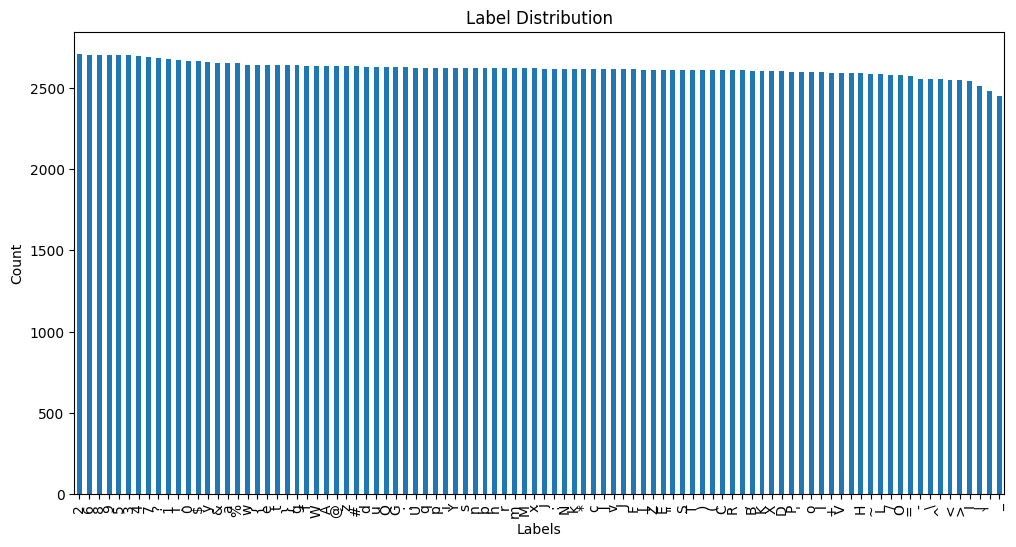

In [66]:
# visualize label distribution
plt.figure(figsize=(12,6))
label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

In [67]:
#checking  outlier pixel values
pixel_values = char[pixel_columns].values
min_pixel_value = pixel_values.min()
max_pixel_value = pixel_values.max()
print(f"min pixel value: {min_pixel_value}")
print(f"max pixel value: {max_pixel_value}")


min pixel value: 0.0
max pixel value: 255.0


# TRAINING

In [68]:
y = char['labels']
X = char.drop(columns=['labels'])

# normalize pixel values to [0,1]
X = X.values.astype('float32') / 255.0
# lebel encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
# transform to one-hot encoding

y_categorical = to_categorical(y_encoded, num_classes)



X_train,X_test,y_train,y_test = train_test_split(X,y_categorical,test_size=0.2,random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"number of classes: {num_classes}")

X_train shape: (197043, 784)
number of classes: 94


In [69]:
#building the model
model=Sequential([Dense(1024, activation='relu', input_shape=(784,)),
                   BatchNormalization(), 
                   Dropout(0.3),
                   Dense(512, activation='relu'),
                   BatchNormalization(),
                   Dropout(0.2),
                   Dense(256, activation='relu'),
                   BatchNormalization(), 
                   Dense(num_classes, activation='softmax')])
#compiling the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization_3 (Batc  (None, 1024)             4096      
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 1024)              0         
                                                                 
 dense_13 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_4 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 512)              

In [70]:
# model training
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,epochs=50,batch_size=128,validation_data=(X_test, y_test),callbacks=[reduce_lr, early_stop],verbose=1)

Epoch 1/50
1540/1540 [==============================] - 38s 23ms/step - loss: 0.6357 - accuracy: 0.8142 - val_loss: 0.4363 - val_accuracy: 0.8628 - lr: 0.0010
Epoch 2/50
1540/1540 [==============================] - 30s 19ms/step - loss: 0.4300 - accuracy: 0.8629 - val_loss: 0.3847 - val_accuracy: 0.8758 - lr: 0.0010
Epoch 3/50
1540/1540 [==============================] - 28s 18ms/step - loss: 0.3776 - accuracy: 0.8760 - val_loss: 0.3629 - val_accuracy: 0.8811 - lr: 0.0010
Epoch 4/50
1540/1540 [==============================] - 29s 19ms/step - loss: 0.3482 - accuracy: 0.8838 - val_loss: 0.3250 - val_accuracy: 0.8963 - lr: 0.0010
Epoch 5/50
1540/1540 [==============================] - 30s 20ms/step - loss: 0.3247 - accuracy: 0.8906 - val_loss: 0.3160 - val_accuracy: 0.8956 - lr: 0.0010
Epoch 6/50
1540/1540 [==============================] - 29s 19ms/step - loss: 0.3060 - accuracy: 0.8958 - val_loss: 0.3215 - val_accuracy: 0.8950 - lr: 0.0010
Epoch 7/50
1540/1540 [========================

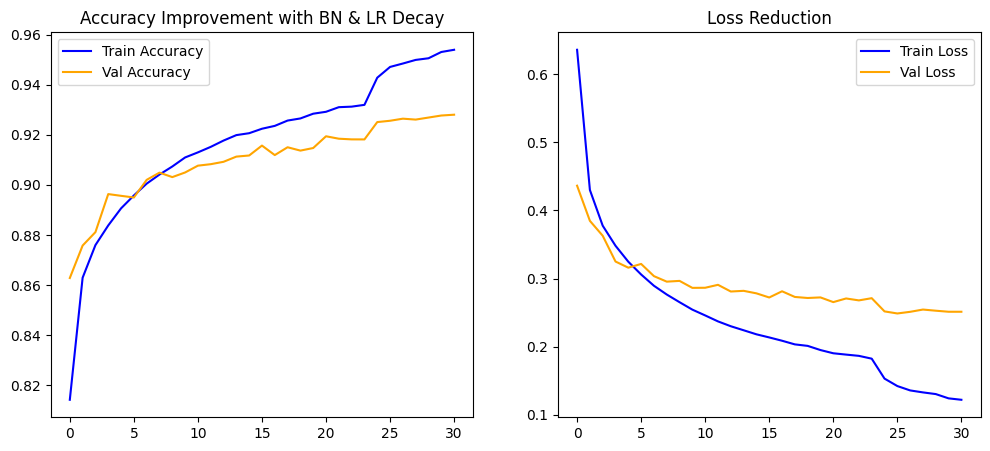

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Accuracy Improvement with BN & LR Decay')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Reduction')
plt.legend()

plt.show()

In [102]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# predict results
y_pred = model.predict(X_test)

# convert probabilities to classes
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# accuracy score
ann_acc = accuracy_score(y_true_classes, y_pred_classes)

print("Accuracy Score:", ann_acc)

# classification report
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=le.classes_
))

1540/1540 [==============================] - 6s 4ms/step
Accuracy Score: 0.925600373520635
              precision    recall  f1-score   support

           !       0.99      0.98      0.98       564
           "       0.98      0.98      0.98       532
           #       0.99      0.98      0.98       514
           $       0.98      0.96      0.97       556
           %       0.99      0.99      0.99       521
           &       0.96      0.94      0.95       535
           '       0.84      0.89      0.87       523
           (       0.98      0.97      0.97       530
           )       0.98      0.98      0.98       541
           *       0.99      0.98      0.99       494
           +       0.99      0.99      0.99       534
           ,       0.91      0.86      0.88       516
           -       0.83      0.83      0.83       507
           .       0.97      0.96      0.97       487
           /       0.89      0.96      0.93       522
           0       0.69      0.66      0.68 

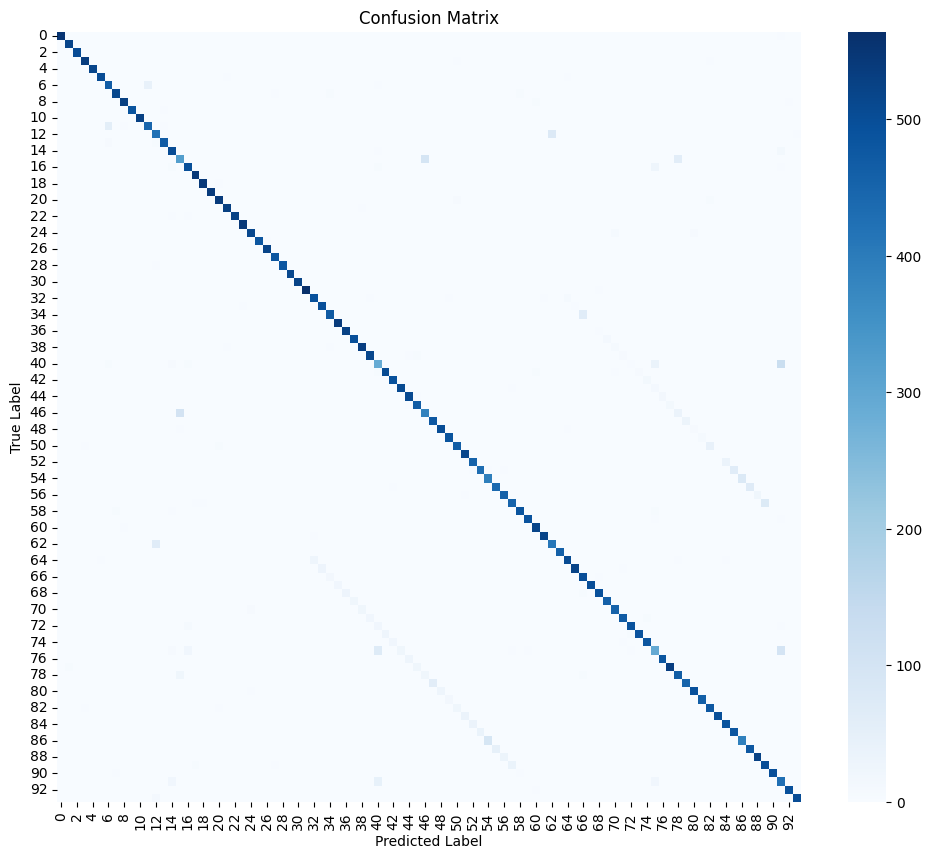

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap='Blues',
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Confusion Matrix Analysis

- Most predictions are concentrated along the main diagonal, indicating strong classification performance.
- The model correctly classifies the majority of character classes.
- A few misclassifications appear between visually similar characters.
- Overall, the confusion matrix demonstrates that the model generalizes well on the test data.

In [92]:
from sklearn.metrics import classification_report
import pandas as pd


report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_, output_dict=True)

df_report = pd.DataFrame(report).transpose()

lowest_performance = df_report.iloc[:-3, :].sort_values(by='f1-score', ascending=True)


print("\n[ANALYSIS] Top 10 Worst Performing Characters:")
print("-" * 45)
print(lowest_performance[['f1-score', 'precision', 'recall']].head(10))

print("\n[ANALYSIS] Top 10 Best Performing Characters:")
print("-" * 45)
print(lowest_performance[['f1-score', 'precision', 'recall']].tail(10))



[ANALYSIS] Top 10 Worst Performing Characters:
---------------------------------------------
   f1-score  precision    recall
I  0.609884   0.630435  0.590631
l  0.623020   0.726601  0.545287
0  0.677149   0.690171  0.664609
|  0.707641   0.616498  0.830409
O  0.736441   0.747104  0.726079
W  0.801628   0.788000  0.815735
w  0.812500   0.822785  0.802469
-  0.828740   0.827112  0.830375
o  0.845662   0.810858  0.883588
_  0.847107   0.835031  0.859539

[ANALYSIS] Top 10 Best Performing Characters:
---------------------------------------------
   f1-score  precision    recall
^  0.986742   0.981168  0.992381
+  0.986891   0.986891  0.986891
=  0.987680   0.989712  0.985656
*  0.987780   0.993852  0.981781
`  0.988185   0.982906  0.993521
:  0.988718   0.985685  0.991770
;  0.989534   0.988593  0.990476
?  0.989534   0.992366  0.986717
%  0.990403   0.990403  0.990403
>  0.995141   0.996109  0.994175


1/1 [==============================] - 0s 22ms/step


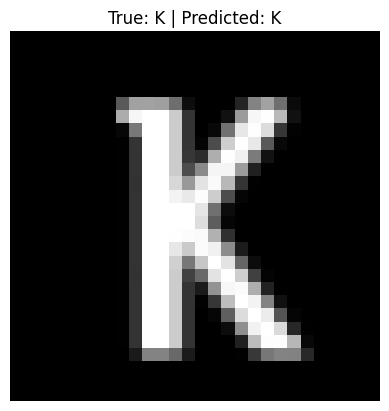

In [74]:
import matplotlib.pyplot as plt

# choose random picture from test set
random_idx = np.random.randint(0, len(X_test))
test_image = X_test[random_idx].reshape(1, 784)
true_label = le.inverse_transform([np.argmax(y_test[random_idx])])[0]

# prediction
prediction = model.predict(test_image)
predicted_label = le.inverse_transform([np.argmax(prediction)])[0]

# show picture
plt.imshow(test_image.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [75]:
# save model
model.save('typography_model.keras')
# lebel encoding saving
joblib.dump(le, 'label_encoder.joblib')


['label_encoder.joblib']

# CNN

In [80]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(f"New Shape for CNN: {X_train_cnn.shape}")

New Shape for CNN: (197043, 28, 28, 1)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

model_cnn = Sequential([
  
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
  
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    
  
    Flatten(),
    
   
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 batch_normalization_12 (Bat  (None, 26, 26, 32)       128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 batch_normalization_13 (Bat  (None, 11, 11, 64)       256       
 chNormalization)                                                
                                                      

In [82]:
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test_cnn, y_test),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/30
1540/1540 [==============================] - 123s 80ms/step - loss: 0.4570 - accuracy: 0.8695 - val_loss: 0.2751 - val_accuracy: 0.9147 - lr: 0.0010
Epoch 2/30
1540/1540 [==============================] - 115s 74ms/step - loss: 0.2595 - accuracy: 0.9177 - val_loss: 0.2502 - val_accuracy: 0.9178 - lr: 0.0010
Epoch 3/30
1540/1540 [==============================] - 120s 78ms/step - loss: 0.2221 - accuracy: 0.9262 - val_loss: 0.2354 - val_accuracy: 0.9230 - lr: 0.0010
Epoch 4/30
1540/1540 [==============================] - 116s 75ms/step - loss: 0.1992 - accuracy: 0.9329 - val_loss: 0.2147 - val_accuracy: 0.9326 - lr: 0.0010
Epoch 5/30
1540/1540 [==============================] - 121s 79ms/step - loss: 0.1834 - accuracy: 0.9373 - val_loss: 0.2391 - val_accuracy: 0.9218 - lr: 0.0010
Epoch 6/30
1540/1540 [==============================] - 124s 81ms/step - loss: 0.1683 - accuracy: 0.9411 - val_loss: 0.2063 - val_accuracy: 0.9342 - lr: 0.0010
Epoch 7/30
1540/1540 [==================

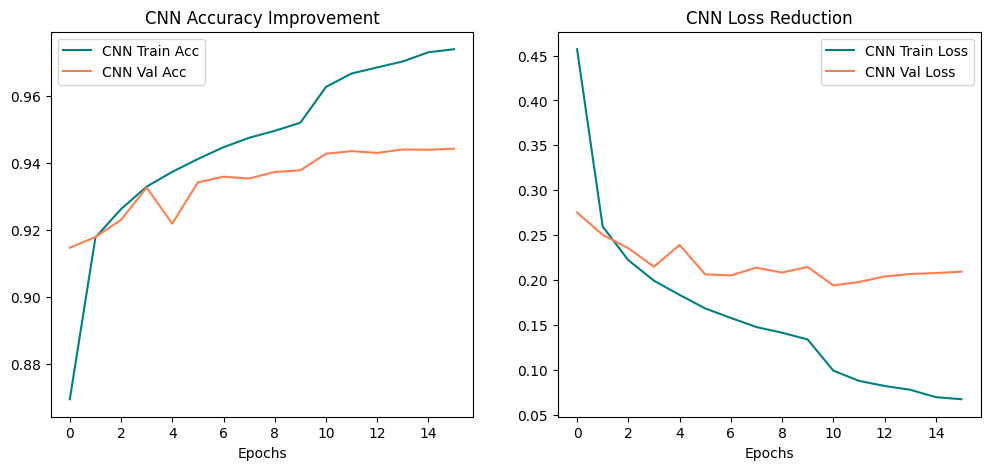

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='CNN Train Acc', color='teal')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc', color='coral')
plt.title('CNN Accuracy Improvement')
plt.xlabel('Epochs')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='CNN Train Loss', color='teal')
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss', color='coral')
plt.title('CNN Loss Reduction')
plt.xlabel('Epochs')
plt.legend()

plt.show()

In [ ]:


# prediction by CNN model
y_pred_cnn = model_cnn.predict(X_test_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)



#  cnn model report
report_cnn = classification_report(y_true_classes, y_pred_classes_cnn, 
                                   target_names=le.classes_, output_dict=True)
print(report_cnn)

df_report_cnn = pd.DataFrame(report_cnn).transpose()

# worse 10
lowest_performance_cnn = df_report_cnn.iloc[:-3, :].sort_values(by='f1-score', ascending=True)

print(" worse 10 in cnn model")
print(lowest_performance_cnn[['f1-score', 'precision', 'recall']].head(10))
print("Best 10")
print(lowest_performance_cnn[['f1-score', 'precision', 'recall']].tail(10))

1540/1540 [==============================] - 11s 7ms/step
{'!': {'precision': 0.9946140035906643, 'recall': 0.9822695035460993, 'f1-score': 0.9884032114183765, 'support': 564.0}, '"': {'precision': 0.9830827067669173, 'recall': 0.9830827067669173, 'f1-score': 0.9830827067669173, 'support': 532.0}, '#': {'precision': 0.9902912621359223, 'recall': 0.9922178988326849, 'f1-score': 0.9912536443148688, 'support': 514.0}, '$': {'precision': 0.9872958257713249, 'recall': 0.9784172661870504, 'f1-score': 0.982836495031617, 'support': 556.0}, '%': {'precision': 0.9980732177263969, 'recall': 0.9942418426103646, 'f1-score': 0.9961538461538462, 'support': 521.0}, '&': {'precision': 0.9847328244274809, 'recall': 0.9644859813084112, 'f1-score': 0.9745042492917847, 'support': 535.0}, "'": {'precision': 0.875, 'recall': 0.8833652007648184, 'f1-score': 0.879162702188392, 'support': 523.0}, '(': {'precision': 0.9864864864864865, 'recall': 0.9641509433962264, 'f1-score': 0.9751908396946565, 'support': 530.

In [103]:


#  Model Prediction using CNN test data (28, 28, 1)
print("Starting Model Prediction...")
y_pred_cnn = model_cnn.predict(X_test_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
print("Prediction Completed Successfully.\n")
# accuracy score
cnn_acc = accuracy_score(y_true_classes, y_pred_classes_cnn)

print("Accuracy Score:", cnn_acc)
# Print Full Classification Report (Vertical Table Format)
print("="*65)
print("DETAILED CNN CLASSIFICATION REPORT")
print("="*65)
# Using the default string output for a clean vertical table
print(classification_report(y_true_classes, y_pred_classes_cnn, target_names=le.classes_))
print("="*65)

#  Create a Dictionary report for statistical analysis
report_dict = classification_report(y_true_classes, y_pred_classes_cnn, 
                                    target_names=le.classes_, output_dict=True)

#  Convert to DataFrame and remove aggregate rows (accuracy, macro avg, etc.)
df_report_cnn = pd.DataFrame(report_dict).transpose()
clean_report_df = df_report_cnn.iloc[:-3, :].sort_values(by='f1-score', ascending=True)




Starting Model Prediction...
1540/1540 [==============================] - 14s 9ms/step
Prediction Completed Successfully.

Accuracy Score: 0.9426930025781044
DETAILED CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

           !       0.99      0.98      0.99       564
           "       0.98      0.98      0.98       532
           #       0.99      0.99      0.99       514
           $       0.99      0.98      0.98       556
           %       1.00      0.99      1.00       521
           &       0.98      0.96      0.97       535
           '       0.88      0.88      0.88       523
           (       0.99      0.96      0.98       530
           )       0.99      0.99      0.99       541
           *       1.00      0.99      0.99       494
           +       0.99      0.99      0.99       534
           ,       0.90      0.89      0.89       516
           -       0.86      0.78      0.82       507
           .       0.97      0.98      0.97       

In [90]:
# 5. Extract and display Worst 10 and Best 10 characters
print("\n[ANALYSIS] Top 10 Worst Performing Characters:")
print("-" * 45)
print(clean_report_df[['f1-score', 'precision', 'recall']].head(10))

print("\n[ANALYSIS] Top 10 Best Performing Characters:")
print("-" * 45)
print(clean_report_df[['f1-score', 'precision', 'recall']].tail(10))



[ANALYSIS] Top 10 Worst Performing Characters:
---------------------------------------------
   f1-score  precision    recall
I  0.650505   0.645291  0.655804
l  0.656716   0.775819  0.569316
0  0.683438   0.696581  0.670782
|  0.728656   0.643284  0.840156
O  0.746562   0.783505  0.712946
-  0.821096   0.863043  0.783037
_  0.845771   0.804924  0.890985
o  0.877350   0.826307  0.935115
'  0.879163   0.875000  0.883365
w  0.880851   0.911894  0.851852

[ANALYSIS] Top 10 Best Performing Characters:
---------------------------------------------
   f1-score  precision    recall
#  0.991254   0.990291  0.992218
@  0.991334   0.994783  0.987910
+  0.991581   0.990654  0.992509
^  0.992366   0.994264  0.990476
*  0.992893   0.995927  0.989879
{  0.993117   0.996055  0.990196
?  0.995252   0.996198  0.994307
%  0.996154   0.998073  0.994242
;  0.996183   0.998088  0.994286
>  0.997090   0.996124  0.998058


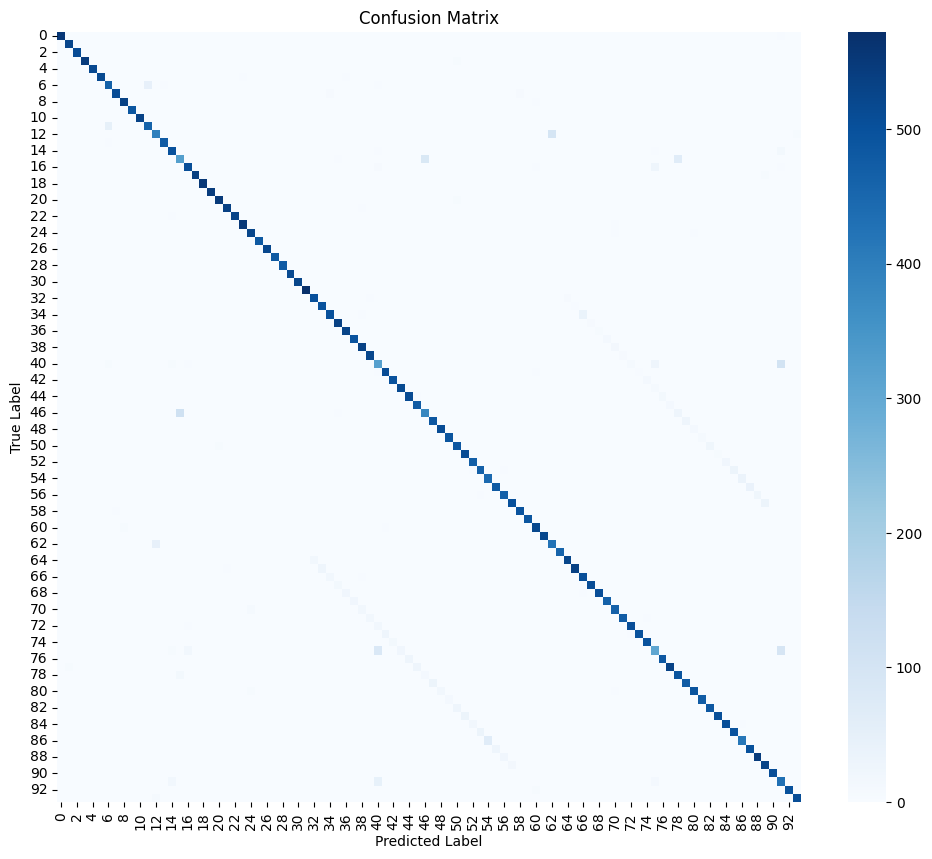

In [101]:


# create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes_cnn)

# plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap='Blues',
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

1/1 [==============================] - 0s 22ms/step


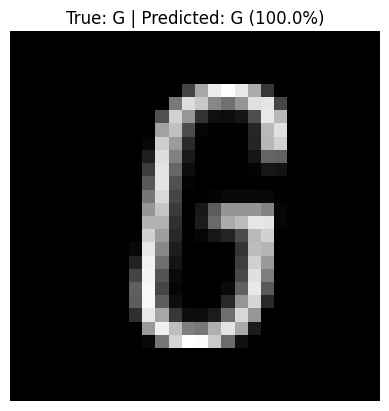

In [86]:
# choose random picture
random_idx = np.random.randint(0, len(X_test_cnn))
test_image_cnn = X_test_cnn[random_idx].reshape(1, 28, 28, 1) # شكل الـ CNN
true_label = le.inverse_transform([np.argmax(y_test[random_idx])])[0]

# predict
prediction_cnn = model_cnn.predict(test_image_cnn)
predicted_label_cnn = le.inverse_transform([np.argmax(prediction_cnn)])[0]
confidence = np.max(prediction_cnn)

# show
plt.imshow(X_test_cnn[random_idx].reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label_cnn} ({confidence:.1%})")
plt.axis('off')
plt.show()

In [91]:
#saving the cnn model
model_cnn.save('typography_model_cnn.keras')

# Model Comparison

In [104]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'Accuracy': [ann_acc, cnn_acc]
})

comparison

,Model,Accuracy
0,ANN,0.925600
1,CNN,0.942693


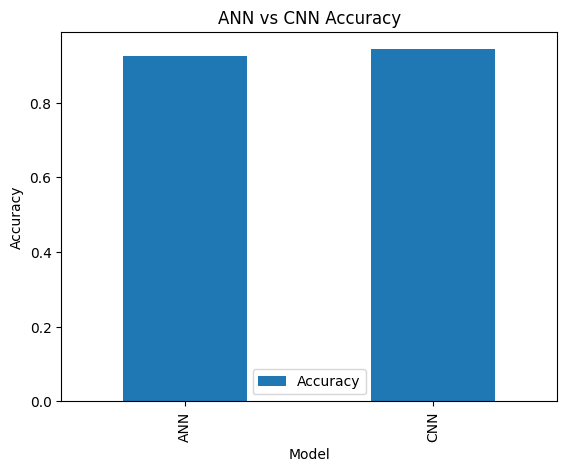

In [105]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title("ANN vs CNN Accuracy")
plt.ylabel("Accuracy")

plt.show()

## Model Comparison Analysis

- The CNN model achieved higher accuracy than the ANN model.
- CNN performed better because it is designed specifically for image data.
- Convolutional layers help CNN capture spatial and visual patterns effectively.
- ANN processes pixels independently, which makes it less efficient for image classification tasks.
- Therefore, CNN is the preferred model for this character recognition problem.